# Analysis of simulated trajectorories

In [1]:
cd ~/work/tutorials/sources/OpenDrift/openberg_july2026

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_july2026


In [15]:
# import pandas as pd
# import xarray as xr
# import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
import glob
# !pip install matplotlib-scalebar
from src.utils import *
from openberg_july2026.src2.utils0 import *
from openberg_july2026.src2.utils2 import *
from openberg_july2026.src2.utils3 import *

In [13]:
%pip install ipympl
%matplotlib widget

Note: you may need to restart the kernel to use updated packages.


In [3]:
ib = 'iceberg2026e'

In [4]:
#read sim
file_contain_all = [ib,'1Jul']
file_contain_any = ['_']
file_notcontain = ['test','15min']#'test','wa','next','glorys']#['topaz4','glorys','slope','era5','almost','stokes',]
file_l = glob.glob("./results/*.nc")#['./results/juliette_topaz6_topaz4_windglophynrt.nc',]
file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
file_l = file_l[::-1]
print(file_l)
# file_l = [
#         # './results/iceberg2026e_gebco_topaz5_windglophynrt_mainrun_1D_mainrun.nc',
#           './results/iceberg2026e_gebco_topaz5_windglophynrt_lead10_mainrun_1D_leadtime10D_mainrun_allmostfull.nc',
#           # './results/iceberg2026e_gebco_topaz5_windglophynrt_idx30-36_debris_radius10000_n20_l50_maxdraft.nc',
#         './results/iceberg2026e_gebco_topaz5_windglophynrt_idx30-36_lead10_debris_radius10000_lead10D__n20_l50_maxdraft.nc'
    
#          ]
# file_l = ['./results/iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_mainrun_longrun_1Jul.nc']

['./results/iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_debris_1Jul_radius10000_n20_l50_maxdraft.nc', './results/iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_mainrun_longrun_1Jul.nc']


In [5]:
#checks
for f in file_l:
    sim=xr.open_dataset(f)
    print(f,sim.trajectory.size,sim.time.size,sim.attrs['config_drift:vertical_profile'],np.all(np.isnan(sim.lat.values)))

./results/iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_debris_1Jul_radius10000_n20_l50_maxdraft.nc 20 1320 False False
./results/iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_mainrun_longrun_1Jul.nc 1 1320 False False


In [6]:
# # Join individual idx files
# fname = 'iceberg2018b_gebco_glorys_windglophyre_prof.nc'
# join_ds_by_idx(file_dict_idx(file_l)[fname]['files'])

# # # #if overlap in trajectories: subset, save, rejoin
# # # test = xr.open_dataset()
# # # test = test.sel(trajectory:np.arange())
# # # test.to_netcdf('.nc','w')

# # #test
# test = xr.open_dataset('./results/'+fname.replace('.nc','_joined.nc'))
# print(np.all(np.isnan(sim.lat.values)), test.trajectory.values)
# test.x_sea_water_velocity.plot()

In [7]:
#dicts and definitions
legenddict_full = {k:v for k,v in legenddict_full.items() if k!='ICEBERG'}
legenddict = dict.fromkeys([f.split('/')[-1][:-3] for f in file_l])
for f in legenddict:
    ll = []
    for l in legenddict_full:
        # print(f,l,ll)
        if l.lower() in f.lower(): ll = ll+[l]
    legenddict[f]={'col':legenddict_full[ll[-1]]['col'], 'alpha':legenddict_full[ll[-1]]['alpha'], 
                   'kw':', '.join(ll),'zo':legenddict_full[ll[-1]]['zo'],
                 # 'traj':np.arange(obs.time.size*11)
                  }
#manual adaptions
# legenddict['iceberg2018b_gebco_topaz6_topaz4_windglophyre_mainrun_joined']['col']='turquoise'
# legenddict['iceberg2018b_gebco_glorys_windglophyre_mainrun_joined']['col']='darkolivegreen'
# legenddict['iceberg2018b_gebco_topaz4_windglophyre_mainrun_joined']['col']='darkslateblue'
legenddict 

{'iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_debris_1Jul_radius10000_n20_l50_maxdraft': {'col': 'grey',
  'alpha': 0.3,
  'kw': 'WINDGLOPHYNRT, TOPAZ5, debris',
  'zo': 9},
 'iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_mainrun_longrun_1Jul': {'col': 'cornflowerblue',
  'alpha': 1,
  'kw': 'WINDGLOPHYNRT, TOPAZ5',
  'zo': 23}}

In [8]:
#read obs
fname = 'merged_obs_iceberg2026e_1D'#'merged_obs10'
with xr.open_dataset('./input/%s.nc'%fname) as ds:
    obs = ds.sel(iceberg=ib,trajectory_id=ib) 
    obs_seed = obs.isel(time=(obs.seed_idx==1))

In [50]:
# obs_sub = obs.sel(time='2026-07-02',method='nearest')
obs_sub.time.data,obs_sub.lon.data,obs_sub.lat.data

(array('2026-07-02T08:13:05.000000000', dtype='datetime64[ns]'),
 array(-24.968),
 array(68.256))

Note: you may need to restart the kernel to use updated packages.


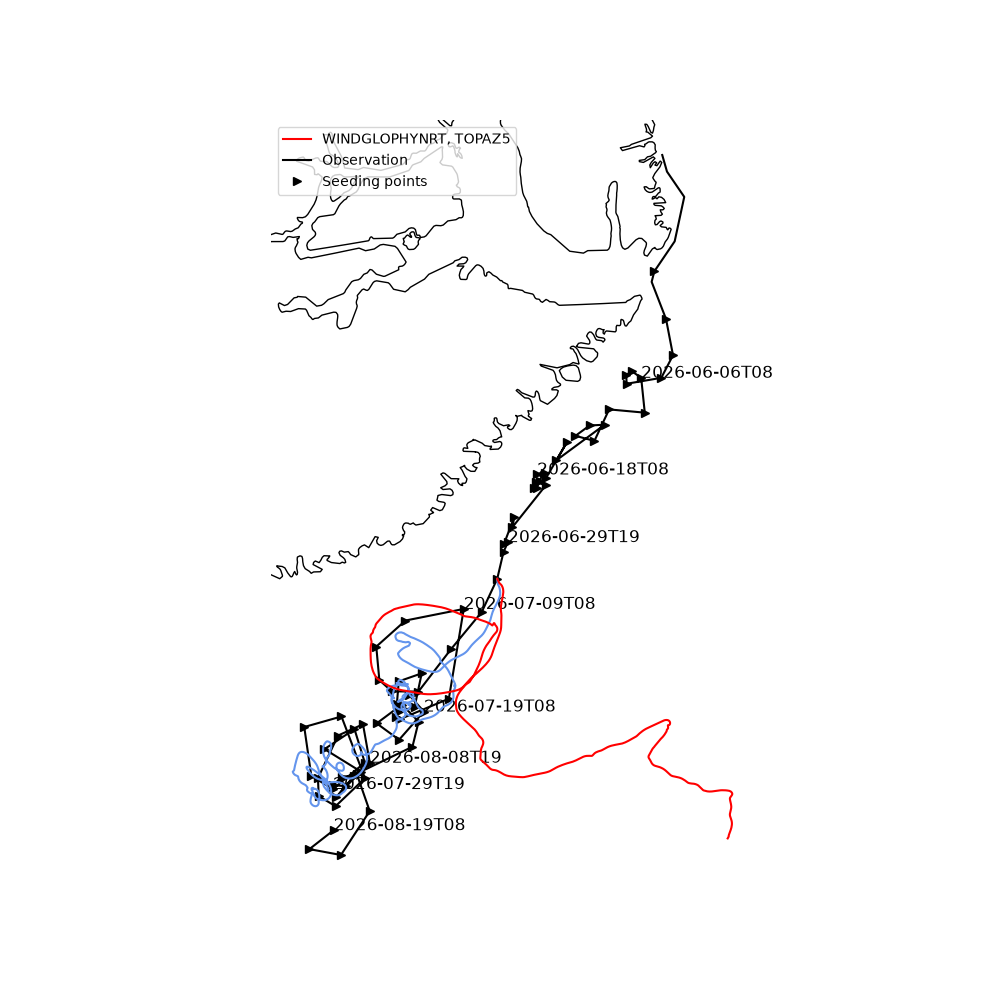

In [63]:
# #very simple plot of simulations
# %pip install ipympl
# %matplotlib widget
# # ib = 'iceberg2018b'
# try: del apn_obs
# except: pass
# apn=None
# # apn = {'time':dict_analysis_period[ib]['full']} #time subset by dict
# # apn = {'time':slice('2026-07-02T08','2026-07-09T08')} #time subset by date
# # apn = obs_seed.time.sel(time=[apn.start,apn.stop],method='nearest') #time subset by seedtime dates -part1
# # apn = slice(str(apn.values[0]),str(apn.values[1])) #time subset by seedtime dates -part2
#     #loop1
# # apn_obs= {'time':slice(obs_seed.time.values[30],obs_seed.time.values[38])} #time subset by seed time idx
#     #loop2
# # apn_obs= {'time':slice(obs_seed.time.values[54],obs_seed.time.values[61])} #time subset by seed time idx
#     #loop3
# # apn_obs= {'time':slice(obs_seed.time.values[60],obs_seed.time.values[70])} #time subset by seed time idx



# #Figure
# fig,ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.NorthPolarStereo(central_longitude=float(obs.lon.mean()))})#central_longitude=20})
# ax.coastlines(resolution='10m')
# trans = ccrs.PlateCarree()

# # # plot obs
# zo1=2
# try: apn_obs
# except: apn_obs=apn
# ax.plot(obs_seed['lon'].sel(apn_obs),obs_seed['lat'].sel(apn_obs),'>',transform=trans,color='k',label='Seeding points',zorder=zo1)
# ax.plot(obs['lon'].sel(apn_obs),obs['lat'].sel(apn_obs),transform=trans,color='k',label='Observation',zorder=zo1)
# # for d in range(obs_3day['time'].size):
# for d in np.arange(obs_seed['time'].sel(apn_obs).size)[::-10]:
# #     if d not in [1,2,3,4,5,12,15,16,17,18,19]:
#         ax.text(obs_seed['lon'].sel(apn_obs)[d],obs_seed['lat'].sel(apn_obs)[d],
#                 obs_seed['time'].sel(apn_obs)[d].values.astype('datetime64[h]').astype(str),transform=trans,color='k',fontsize=12,zorder=zo1)


# # plot sim
# zo2=10
# for inputdataidx, inputdata in enumerate(file_l[::-1]):
#     sim = xr.open_dataset(inputdata)
#     inputdata = inputdata.split('/')[-1][:-3]
#     # apn = {'trajectory':slice(30,37)} if 'mainrun' in inputdata else {'trajectory':slice(0,20*8)} #loop1
#     # apn = {'trajectory':slice(54,60)} if 'mainrun' in inputdata else {'trajectory':slice(0,140)} #loop2
#     # apn = {'trajectory':slice(60,70)} if 'mainrun' in inputdata else {'trajectory':slice(141,290)} #loop3
#     if apn!=None: sim = sim.sel(apn)
#     if ib in dict_traj: 
#         if inputdata in dict_traj[ib]: sim = sim.sel(trajectory=dict_traj[ib][inputdata])
#     for traj in sim.trajectory:
#         ax.plot(sim.lon.sel(trajectory=traj).dropna(dim="time"),sim.lat.sel(trajectory=traj).dropna(dim="time"),
#                 color=legenddict[inputdata]['col'] if '15min' not in inputdata else 'red',
#                 label=legenddict[inputdata]['kw'] if traj==sim.trajectory[0] else '',#) if 'mainrun' not in inputdata else '',
#                 zorder=legenddict[inputdata]['zo'],
#                 alpha=legenddict[inputdata]['alpha'],
#                 linestyle='-' if '10D' not in inputdata else ':',#) if 'debris' not in inputdata else ':',
#                 transform=trans)

# #legend
# h, l = ax.get_legend_handles_labels()
# by_label = dict(zip(l, h))
# ax.legend(handles=list(by_label.values())[::-1],
#          labels=list(by_label.keys())[::-1],
#           loc='best')
         
# # plt.legend()
# plt.axis('off')
# # note = ''
# # fig.savefig('./results/%s_map_%s.png'%(iceberg_id,note),dpi=200,transparent=True,bbox_inches='tight')
# plt.show()



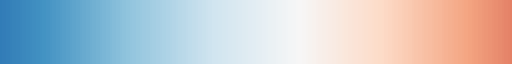

In [23]:
from matplotlib.colors import LinearSegmentedColormap
pastel_cmap = LinearSegmentedColormap.from_list('past_cmap',
plt.cm.RdBu_r(np.linspace(0.15, 0.75, 256)))
pastel_cmap

iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_mainrun_longrun_1Jul {'trajectory': [0]}
iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_debris_1Jul_radius10000_n20_l50_maxdraft {'trajectory': slice(0, 21, None)}


/opt/conda/lib/python3.12/site-packages/dask/array/core.py:1735: FutureWarning: The `numpy.column_stack` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(
/tmp/ipykernel_36652/273300776.py:111: UserWarning: Legend does not support handles for GeoQuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  h, l = ax.get_legend_handles_labels()


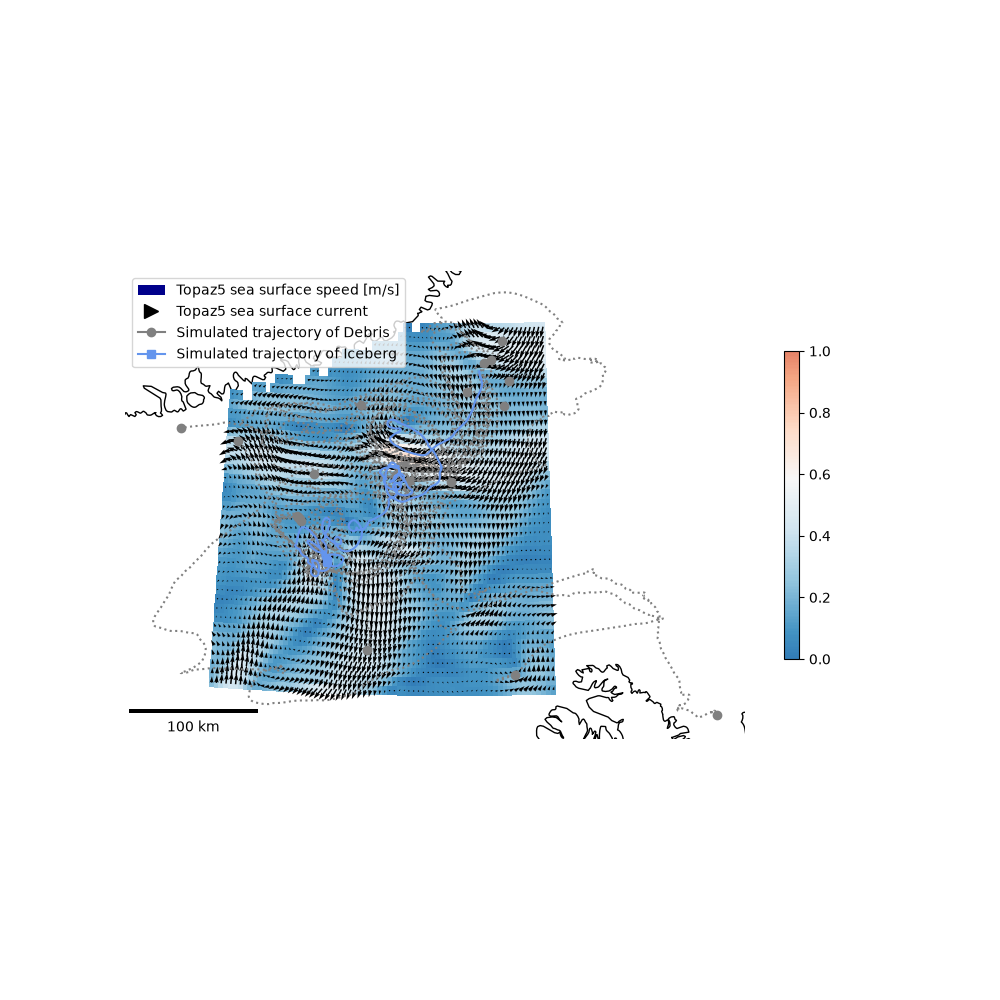

In [24]:
# --- Plot for news story ---
# %pip install ipympl
# %matplotlib widget
try: del apn_obs
except: pass
apn=None
# #loop1
# apn_obs= {'time':slice(obs_seed.time.values[30],obs_seed.time.values[37])} #time subset by seed time idx
# # apn = {'trajectory':slice(30,37)} if 'mainrun' in inputdata else {'trajectory':slice(0,20*8)} #loop1
# apn_add = {'time':slice('2026-07-02','2026-07-12')}
# apni = 30
#after 1Jul
apn_obs= {'time':slice(obs_seed.time.values[30],obs_seed.time.values[-1])} #time subset by seed time idx
apn_add = {'time':slice('2026-07-01','2026-08-25')}
apni = 0


#def
# legenddict['iceberg2026e_gebco_topaz5_windglophynrt_lead10_mainrun_1D_leadtime10D_mainrun_allmostfull']['kw'] = 'Simulated trajectory of Iceberg'
# legenddict['iceberg2026e_gebco_topaz5_windglophynrt_idx30-36_lead10_debris_radius10000_lead10D__n20_l50_maxdraft']['kw'] = 'Simulated trajectory of Debris'
legenddict['iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_mainrun_longrun_1Jul']['kw'] = 'Simulated trajectory of Iceberg'
legenddict['iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_debris_1Jul_radius10000_n20_l50_maxdraft']['kw'] = 'Simulated trajectory of Debris'

#cmems data 
try: cmems
except:
    # #load cmems data
    import copernicusmarine as cm
    cmems = cm.open_dataset(
        dataset_id='cmems_mod_arc_phy_anfc_6km_detided_PT1H-i',
        # variables=vars_cmems,
        minimum_longitude=obs.sel(apn_obs).lon.min()-1.5,
        maximum_longitude=obs.sel(apn_obs).lon.max()+1.5,
        minimum_latitude=obs.sel(apn_obs).lat.min()-0.5,
        maximum_latitude=obs.sel(apn_obs).lat.max()+0.5,
        start_datetime=str(apn_obs['time'].start),#str(obstime[0].values),
        end_datetime=str(apn_obs['time'].stop),#str(obstime[1].values),
    )
    
#Figure
fig,ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.NorthPolarStereo(central_longitude=float(obs.lon.mean()))})#central_longitude=20})
ax.coastlines(resolution='10m')
trans = ccrs.PlateCarree()

# # # plot obs
# zo1=2
# try: apn_obs
# except: apn_obs=apn
# ax.plot(obs_seed['lon'].sel(apn_obs),obs_seed['lat'].sel(apn_obs),'>',transform=trans,color='k',label='Seeding points',zorder=zo1)
# ax.plot(obs['lon'].sel(apn_obs),obs['lat'].sel(apn_obs),transform=trans,color='k',label='Observation',zorder=zo1)
# # for d in range(obs_3day['time'].size):
# for d in np.arange(obs_seed['time'].sel(apn_obs).size)[::-10]:
# #     if d not in [1,2,3,4,5,12,15,16,17,18,19]:
#         ax.text(obs_seed['lon'].sel(apn_obs)[d],obs_seed['lat'].sel(apn_obs)[d],
#                 obs_seed['time'].sel(apn_obs)[d].values.astype('datetime64[h]').astype(str),transform=trans,color='k',fontsize=12,zorder=zo1)


# plot sim
zo2=10
for inputdataidx, inputdata in enumerate(file_l[::-1]):
    sim = xr.open_dataset(inputdata)
    inputdata = inputdata.split('/')[-1][:-3]
    # apn = {'trajectory':[apni]} if 'mainrun' in inputdata else {'trajectory':slice((apni-30)*20+5,(apni-29)*20+1+5)} #loop1
    apn = {'trajectory':[apni]} if 'mainrun' in inputdata else {'trajectory':slice(apni*20,(1+apni)*20+1)} #1Jul
    print(inputdata,apn)
    if apn!=None: sim = sim.sel(apn)
    if apn_add!=None: sim = sim.sel(apn_add)
    if ib in dict_traj: 
        if inputdata in dict_traj[ib]: sim = sim.sel(trajectory=dict_traj[ib][inputdata])
    for traj in sim.trajectory if sim.trajectory.size>1 else [apni,]:
        ax.plot(sim.lon.sel(trajectory=traj).dropna(dim="time"),sim.lat.sel(trajectory=traj).dropna(dim="time"),
                color=legenddict[inputdata]['col'], #if 'prof' not in inputdata else 'red',
                label=legenddict[inputdata]['kw'] if traj in (apni,(apni-30)*20) else '',#) if 'mainrun' not in inputdata else '',
                zorder=legenddict[inputdata]['zo'] if 'debris' not in inputdata else 20,
                alpha=legenddict[inputdata]['alpha'] if 'debris' not in inputdata else 1,
                linestyle='-' if 'debris' not in inputdata else ':',#'-' if '10D' not in inputdata else ':',#) 
                transform=trans)
        # if '10D' in inputdata:
        ax.plot(sim.lon.sel(trajectory=traj).dropna(dim="time")[-1],sim.lat.sel(trajectory=traj).dropna(dim="time")[-1],
                color=legenddict[inputdata]['col'], #if 'prof' not in inputdata else 'red',
                label=legenddict[inputdata]['kw'], # if traj in (apni,(apni-30)*20) else '',#) if 'mainrun' not in inputdata else '',
                zorder=legenddict[inputdata]['zo'] if 'debris' not in inputdata else 20,
                alpha=legenddict[inputdata]['alpha'] if 'debris' not in inputdata else 1,
                marker='s' if 'debris' not in inputdata else 'o',#) if 'debris' not in inputdata else ':',
                transform=trans)


#plot background
# b=ax.contourf(cmems.longitude,cmems.latitude,cmems.thetao.sel(time=apn_obs['time'].start,method='nearest'),
#             cmap='RdBu_r',levels=np.arange(-3,3,0.2), vmin=-3,vmax=3,extend='max',
#               alpha=0.5,transform=trans,zorder=3)
# val_b, label_b,vlim_b = cmems.thetao.sel(time=apn_obs['time'].start,method='nearest'),'Topaz5 sea surface temperature,(-3,3)
val_b = np.hypot(cmems.vxo.sel(time=apn_obs['time'].start,method='nearest'),
         cmems.vyo.sel(time=apn_obs['time'].start,method='nearest'))
label_b,vlim_b = 'Topaz5 sea surface speed',(0,1)
b = ax.pcolormesh(cmems.longitude,cmems.latitude,val_b,
            cmap=pastel_cmap,
            vmin=vlim_b[0],vmax=vlim_b[-1],
            alpha=1,transform=trans,zorder=3,
                 label=label_b)
plt.colorbar(b,shrink=0.4)
d=1
ax.quiver(cmems.longitude[::d].data,cmems.latitude[::d].data,
          cmems.vxo.sel(time=apn_obs['time'].start,method='nearest')[::d,::d].data,
          cmems.vyo.sel(time=apn_obs['time'].start,method='nearest')[::d,::d].data,
         transform=trans,zorder=4,
         label='Topaz5 sea surface current')

#legend
# from matplotlib.legend_handler import HandlerQuiver
h, l = ax.get_legend_handles_labels()
by_label = dict(zip(l, h))
by_label['Topaz5 sea surface current'] = Line2D([], [],color='k',marker='>',markersize=10,linestyle='None',label='0.1 m s$^{-1}$')
by_label['Topaz5 sea surface speed [m/s]']=Patch(facecolor='darkblue')
ax.legend(handles=list(by_label.values())[::-1],
         labels=list(by_label.keys())[::-1],
          # handler_map={type(by_label['Topaz5 sea surface current']): HandlerQuiver()},
          loc='best')
# plt.legend()

#scale bar
from matplotlib_scalebar.scalebar import ScaleBar

scalebar = ScaleBar(
    dx=1,           # data units are meters
    units="m",
    fixed_value=100,
    fixed_units="km",
    location="lower left",
    frameon=True,
    box_color="white",
    box_alpha=0.8,
)

ax.add_artist(scalebar)

plt.axis('off')
note = ''
fig.savefig('./results/%s_map_%s.png'%(ib,note),dpi=200,transparent=True,bbox_inches='tight')
plt.show()




iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_mainrun_longrun_1Jul {'trajectory': [0]}
iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_debris_1Jul_radius10000_n20_l50_maxdraft {'trajectory': slice(0, 21, None)}


/opt/conda/lib/python3.12/site-packages/dask/array/core.py:1735: FutureWarning: The `numpy.column_stack` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(


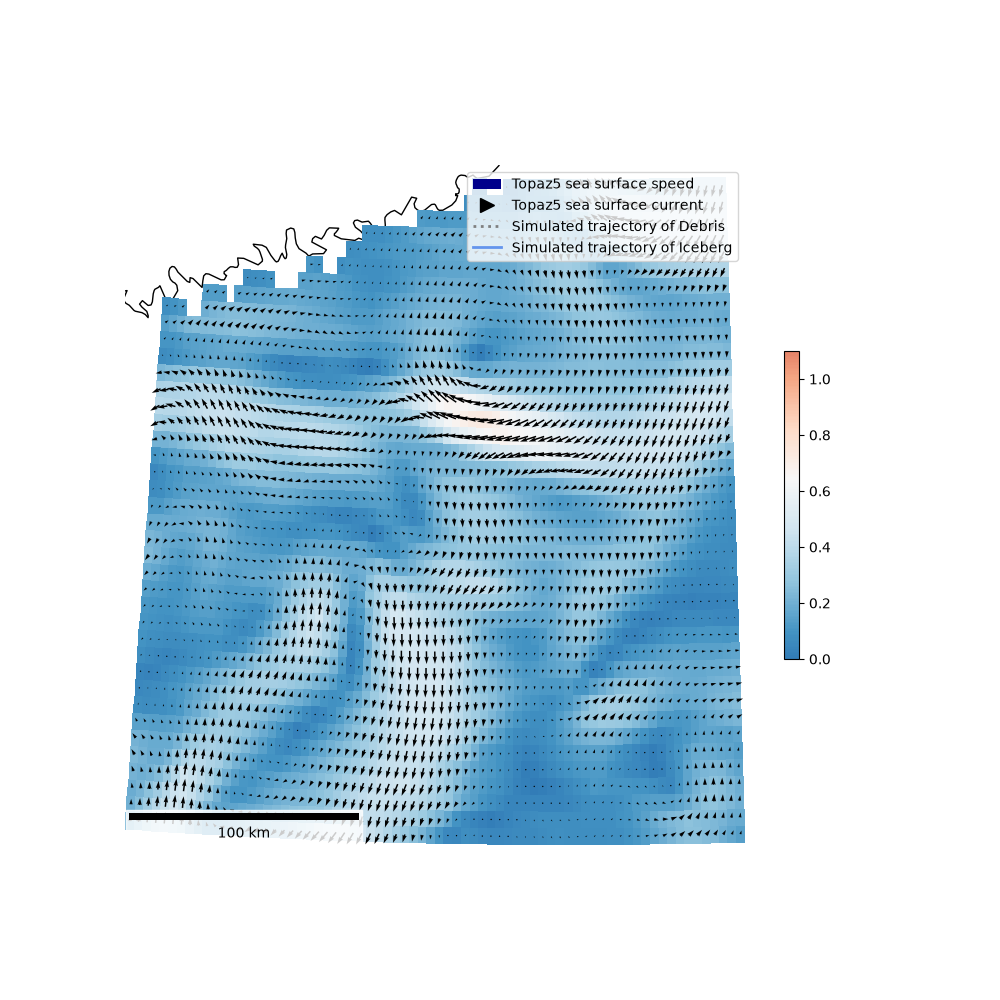

In [36]:
# --- Plot for news story --- BUT ANIMATED------------------------------------------------

try: del apn_obs
except: pass
apn=None
# #loop1
# apn_obs= {'time':slice(obs_seed.time.values[30],obs_seed.time.values[37])} #time subset by seed time idx
# apn_add = {'time':slice('2026-07-02','2026-07-12')}
# apni = 30
#after 1Jul
apn_obs= {'time':slice(obs_seed.time.values[30],obs_seed.time.values[-1])} #time subset by seed time idx
apn_add = {'time':slice('2026-07-01','2026-08-25')}
apni = 0

#def
# legenddict['iceberg2026e_gebco_topaz5_windglophynrt_lead10_mainrun_1D_leadtime10D_mainrun_allmostfull']['kw'] = 'Simulated trajectory of Iceberg'
# legenddict['iceberg2026e_gebco_topaz5_windglophynrt_idx30-36_lead10_debris_radius10000_lead10D__n20_l50_maxdraft']['kw'] = 'Simulated trajectory of Debris'
legenddict['iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_mainrun_longrun_1Jul']['kw'] = 'Simulated trajectory of Iceberg'
legenddict['iceberg2026e_gebco_topaz5_windglophynrt_idx29-29_lead55_debris_1Jul_radius10000_n20_l50_maxdraft']['kw'] = 'Simulated trajectory of Debris'

#cmems data 
try: cmems
except:
    # #load cmems data
    import copernicusmarine as cm
    cmems = cm.open_dataset(
        dataset_id='cmems_mod_arc_phy_anfc_6km_detided_PT1H-i',
        # variables=vars_cmems,
        minimum_longitude=obs.sel(apn_obs).lon.min()-1.5,
        maximum_longitude=obs.sel(apn_obs).lon.max()+1.5,
        minimum_latitude=obs.sel(apn_obs).lat.min()-0.5,
        maximum_latitude=obs.sel(apn_obs).lat.max()+0.5,
        start_datetime=str(apn_obs['time'].start),#str(obstime[0].values),
        end_datetime=str(apn_obs['time'].stop),#str(obstime[1].values),
    )

#Figure
fig,ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.NorthPolarStereo(central_longitude=float(obs.lon.mean()))})#central_longitude=20})
ax.coastlines(resolution='10m')
trans = ccrs.PlateCarree()

# # # plot obs
# zo1=9
# try: apn_obs
# except: apn_obs=apn
# ax.plot(obs_seed['lon'].sel(apn_obs),obs_seed['lat'].sel(apn_obs),'>',transform=trans,color='k',label='Seeding points',zorder=zo1)
# ax.plot(obs['lon'].sel(apn_obs),obs['lat'].sel(apn_obs),transform=trans,color='k',label='Observation',zorder=zo1)
# # for d in range(obs_3day['time'].size):
# for d in np.arange(obs_seed['time'].sel(apn_obs).size)[::-10]:
# #     if d not in [1,2,3,4,5,12,15,16,17,18,19]:
#         ax.text(obs_seed['lon'].sel(apn_obs)[d],obs_seed['lat'].sel(apn_obs)[d],
#                 obs_seed['time'].sel(apn_obs)[d].values.astype('datetime64[h]').astype(str),transform=trans,color='k',fontsize=12,zorder=zo1)


# plot sim
zo2=10
traj_lines = []
for inputdataidx, inputdata in enumerate(file_l[::-1]):
    sim = xr.open_dataset(inputdata)
    inputdata = inputdata.split('/')[-1][:-3]
    # apn = {'trajectory':[apni]} if 'mainrun' in inputdata else {'trajectory':slice((apni-30)*20+5,(apni-29)*20+1+5)} #loop1
    apn = {'trajectory':[apni]} if 'mainrun' in inputdata else {'trajectory':slice(apni*20,(1+apni)*20+1)} #1Jul
    print(inputdata,apn)
    if apn!=None: sim = sim.sel(apn)
    if apn_add!=None: sim = sim.sel(apn_add)
    if ib in dict_traj: 
        if inputdata in dict_traj[ib]: sim = sim.sel(trajectory=dict_traj[ib][inputdata])
    for traj in sim.trajectory if sim.trajectory.size>1 else [apni,]:
        line,=ax.plot([],[],#sim.lon.sel(trajectory=traj).dropna(dim="time"),sim.lat.sel(trajectory=traj).dropna(dim="time"),
                color=legenddict[inputdata]['col'], #if 'prof' not in inputdata else 'red',
                label=legenddict[inputdata]['kw'] if traj in (apni,(apni-30)*20) else '',#) if 'mainrun' not in inputdata else '',
                zorder=legenddict[inputdata]['zo'] if 'debris' not in inputdata else 20,
                alpha=legenddict[inputdata]['alpha'] if 'debris' not in inputdata else 1,
                linestyle='-' if 'debris' not in inputdata else ':',#'-' if '10D' not in inputdata else ':',#) 
                lw=2,
                transform=trans)
        traj_lines.append({
        'line': line,
        'lon': sim.lon.sel(trajectory=traj).dropna("time"),
        'lat': sim.lat.sel(trajectory=traj).dropna("time"),
        'time': sim.lon.time
        })
        # if '10D' in inputdata:
        #     ax.plot(sim.lon.sel(trajectory=traj).dropna(dim="time")[-1],sim.lat.sel(trajectory=traj).dropna(dim="time")[-1],
        #             color=legenddict[inputdata]['col'], #if 'prof' not in inputdata else 'red',
        #             label=legenddict[inputdata]['kw'], # if traj in (apni,(apni-30)*20) else '',#) if 'mainrun' not in inputdata else '',
        #             zorder=legenddict[inputdata]['zo'] if 'debris' not in inputdata else 20,
        #             alpha=legenddict[inputdata]['alpha'] if 'debris' not in inputdata else 1,
        #             marker='s' if 'debris' not in inputdata else 'o',#) if 'debris' not in inputdata else ':',
        #             transform=trans)


#plot background
t0=apn_obs['time'].start
# b=ax.contourf(cmems.longitude,cmems.latitude,cmems.thetao.sel(time=apn_obs['time'].start,method='nearest'),
#             cmap='RdBu_r',levels=np.arange(-3,3,0.2), vmin=-3,vmax=3,extend='max',
#               alpha=0.5,transform=trans,zorder=3)

# val_b, label_b,vlim_b = cmems.thetao.sel(time=t0,method='nearest'),'Topaz5 sea surface temperature,(-3,3)
val_b = np.hypot(cmems.vxo.sel(time=t0,method='nearest'),
         cmems.vyo.sel(time=t0,method='nearest'))
label_b,vlim_b = 'Topaz5 sea surface speed',(0,1.1)
norm = Normalize(vmin=vlim_b[0], vmax=vlim_b[1])
cf = ax.pcolormesh(cmems.longitude,cmems.latitude,val_b,
            cmap=pastel_cmap,
            # vmin=vlim_b[0],vmax=vlim_b[-1],
           norm=norm,
            alpha=1,transform=trans,zorder=3,
                 label=label_b)
plt.colorbar(cf,shrink=0.4)
d=1
quiv = ax.quiver(cmems.longitude[::d].data,cmems.latitude[::d].data,
          cmems.vxo.sel(time=t0,method='nearest')[::d,::d].data,
          cmems.vyo.sel(time=t0,method='nearest')[::d,::d].data,
         transform=trans,zorder=4,
         label='Topaz5 sea surface current')

#legend
# from matplotlib.legend_handler import HandlerQuiver
# h, l = ax.get_legend_handles_labels()
by_label = {}#dict(zip(l, h))
for inputdataidx, inputdata in enumerate(file_l[::-1]):
    inputdata = inputdata.split('/')[-1][:-3]
    by_label[legenddict[inputdata]['kw']] = Line2D([], [],color=legenddict[inputdata]['col'],linestyle='-' if 'debris' not in inputdata else ':',lw=2)
by_label['Topaz5 sea surface current'] = Line2D([], [],color='k',marker='>',markersize=10,linestyle='None')
by_label['Topaz5 sea surface speed']=Patch(facecolor='darkblue')
ax.legend(handles=list(by_label.values())[::-1],
         labels=list(by_label.keys())[::-1],
          # handler_map={type(by_label['Topaz5 sea surface current']): HandlerQuiver()},
          loc='best')
# plt.legend()

#scale bar
from matplotlib_scalebar.scalebar import ScaleBar

scalebar = ScaleBar(
    dx=1,           # data units are meters
    units="m",
    fixed_value=100,
    fixed_units="km",
    location="lower left",
    frameon=True,
    box_color="white",
    box_alpha=0.8,
)

ax.add_artist(scalebar)

plt.axis('off')
note = 'newscase_idx30'
# fig.savefig('./results/%s_map_%s.png'%(ib,note),dpi=200,transparent=True,bbox_inches='tight')
# plt.show()




In [37]:
# times = obs_seed.time.sel(apn_obs).values
times = np.arange(apn_add['time'].start,apn_add['time'].stop,dtype=np.datetime64)
nframes = len(times)

In [38]:
def update(i):

    t = times[i]

    # update background field
    cf.set_array(
        # cmems.thetao.sel(time=t, method='nearest').values.ravel()
        np.ravel(np.hypot(cmems.vxo.sel(time=t,method='nearest'),
         cmems.vyo.sel(time=t,method='nearest')))
    )

    # update currents
    quiv.set_UVC(
        cmems.vxo.sel(time=t, method='nearest')[::d,::d].values,
        cmems.vyo.sel(time=t, method='nearest')[::d,::d].values
    )

    # grow trajectories
    for tr in traj_lines:

        lon_now = tr['lon'].sel(time=slice(None, t))
        lat_now = tr['lat'].sel(time=slice(None, t))
        # lon_now = tr['lon'].where(tr['lon'].time <= t, drop=True)
        # lat_now = tr['lat'].where(tr['lat'].time <= t, drop=True)
    
        tr['line'].set_data(
            lon_now.values,
            lat_now.values)


    ax.set_title(str(t))

    return [cf, quiv]

In [39]:
from matplotlib.animation import FuncAnimation

ani = FuncAnimation(
    fig,
    update,
    frames=nframes,
    interval=300,
    blit=False
)

ani.save(
    "./results/iceberg2026e.gif",
    writer="pillow")
 

In [40]:
# update(-1)

# fig.savefig("./results/iceberg2026e_frame-1.png")